## Load and handle Dataset

In [37]:
import csv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LSTM, Dropout, Activation, Embedding, Bidirectional,SimpleRNN
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
vocab_size = 5000
embedding_dim = 64
max_length = 200
oov_tok = '<OOV>' #  Out of Vocabulary
training_portion = 0.8

In [39]:
import pandas as pd

df = pd.read_csv('bbc-text.csv')

In [40]:
df

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,business,cars pull down us retail figures us retail sal...
2221,politics,kilroy unveils immigration policy ex-chatshow ...
2222,entertainment,rem announce new glasgow concert us band rem h...
2223,politics,how political squabbles snowball it s become c...


In [41]:
df['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [42]:
articles = df['text'].values
labels = df['category'].values

In [43]:
len(labels),len(articles)

(2225, 2225)

In [44]:
labels[0],articles[0]

('tech',
 'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-

In [45]:
# split data into train and validation using sklearn
from sklearn.model_selection import train_test_split
train_articles, validation_articles, train_labels, validation_labels = train_test_split(articles, labels, test_size=0.2, random_state=42)


In [46]:
print('train_articles' ,len(train_articles))
print('train_labels', len(train_labels))
print('validation_articles', len(validation_articles))
print('validation_labels', len(validation_labels))

train_articles 1780
train_labels 1780
validation_articles 445
validation_labels 445


In [47]:
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_articles)
word_index = tokenizer.word_index

In [48]:
word_index

{'<OOV>': 1,
 'the': 2,
 'to': 3,
 'of': 4,
 'and': 5,
 'a': 6,
 'in': 7,
 's': 8,
 'for': 9,
 'is': 10,
 'that': 11,
 'it': 12,
 'on': 13,
 'said': 14,
 'was': 15,
 'he': 16,
 'be': 17,
 'with': 18,
 'has': 19,
 'as': 20,
 'have': 21,
 'at': 22,
 'by': 23,
 'will': 24,
 'but': 25,
 'are': 26,
 'i': 27,
 'from': 28,
 'not': 29,
 'his': 30,
 'they': 31,
 'mr': 32,
 'we': 33,
 'this': 34,
 'an': 35,
 'had': 36,
 'would': 37,
 'which': 38,
 'been': 39,
 'their': 40,
 'year': 41,
 'more': 42,
 'up': 43,
 'its': 44,
 'were': 45,
 'also': 46,
 'who': 47,
 'new': 48,
 'people': 49,
 'one': 50,
 'us': 51,
 'there': 52,
 'about': 53,
 'after': 54,
 'out': 55,
 'can': 56,
 'than': 57,
 'all': 58,
 'or': 59,
 'if': 60,
 'you': 61,
 'could': 62,
 'over': 63,
 'last': 64,
 'first': 65,
 'when': 66,
 't': 67,
 'time': 68,
 'two': 69,
 'world': 70,
 'some': 71,
 'government': 72,
 'into': 73,
 'other': 74,
 'now': 75,
 'she': 76,
 'what': 77,
 'uk': 78,
 'so': 79,
 'years': 80,
 'only': 81,
 'against

In [49]:
tokenizer.texts_to_sequences(['the cat sat on my table'])

[[2, 1, 1, 13, 127, 2286]]

In [50]:
train_sequences = tokenizer.texts_to_sequences(train_articles)
len(train_sequences)

1780

In [51]:
len(train_sequences[8]),


(522,)

In [52]:
train_padded = pad_sequences(train_sequences, maxlen=max_length,)

In [53]:
len(train_padded),len(train_padded[0])

(1780, 200)

In [54]:
len(train_sequences[8]),len(train_padded[8])

(522, 200)

In [55]:
validation_sequences = tokenizer.texts_to_sequences(validation_articles)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length)

In [56]:
set(labels)

{'business', 'entertainment', 'politics', 'sport', 'tech'}

In [57]:
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(labels)

training_label_seq = np.array(label_tokenizer.texts_to_sequences(train_labels))
validation_label_seq = np.array(label_tokenizer.texts_to_sequences(validation_labels))

In [58]:
label_tokenizer.word_index

{'sport': 1, 'business': 2, 'politics': 3, 'tech': 4, 'entertainment': 5}

In [59]:
train_labels

array(['entertainment', 'business', 'business', ..., 'tech', 'sport',
       'tech'], shape=(1780,), dtype=object)

In [60]:
training_label_seq

array([[5],
       [2],
       [2],
       ...,
       [4],
       [1],
       [4]], shape=(1780, 1))

In [61]:
train_labels[0], training_label_seq[0]

('entertainment', array([5]))

## Apply RNN

In [62]:

model = Sequential()
model.add(Embedding(vocab_size,embedding_dim , input_length=100))
model.build(input_shape=(None, 100))
model.add(Dropout(0.2))
model.add(SimpleRNN(units = embedding_dim))
model.add(Dropout(0.2))
model.add(Dense(6,activation='softmax'))
model.summary()

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,646 (1.25 MB)

 Trainable params: 328,646 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import AdamW

K.clear_session()

adam_w = AdamW(learning_rate=0.001)

In [64]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [65]:
num_epochs = 20
history = model.fit(train_padded, training_label_seq, epochs=num_epochs,
                    validation_data=(validation_padded, validation_label_seq),
                    verbose=2)

Epoch 1/20
56/56 - 3s - 46ms/step - accuracy: 0.2124 - loss: 1.6834 - val_accuracy: 0.2697 - val_loss: 1.6101
Epoch 2/20
56/56 - 1s - 18ms/step - accuracy: 0.4388 - loss: 1.4848 - val_accuracy: 0.2899 - val_loss: 1.5737
Epoch 3/20
56/56 - 1s - 18ms/step - accuracy: 0.7213 - loss: 1.0889 - val_accuracy: 0.3236 - val_loss: 1.6095
Epoch 4/20
56/56 - 1s - 18ms/step - accuracy: 0.9112 - loss: 0.5901 - val_accuracy: 0.3303 - val_loss: 1.6618
Epoch 5/20
56/56 - 1s - 18ms/step - accuracy: 0.9787 - loss: 0.2607 - val_accuracy: 0.3281 - val_loss: 1.7972
Epoch 6/20
56/56 - 1s - 18ms/step - accuracy: 0.9972 - loss: 0.0953 - val_accuracy: 0.3213 - val_loss: 1.9147
Epoch 7/20
56/56 - 1s - 18ms/step - accuracy: 1.0000 - loss: 0.0449 - val_accuracy: 0.3191 - val_loss: 2.0060
Epoch 8/20
56/56 - 1s - 18ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 0.3303 - val_loss: 2.0610
Epoch 9/20
56/56 - 1s - 18ms/step - accuracy: 1.0000 - loss: 0.0212 - val_accuracy: 0.3303 - val_loss: 2.1345
Epoch 10/2

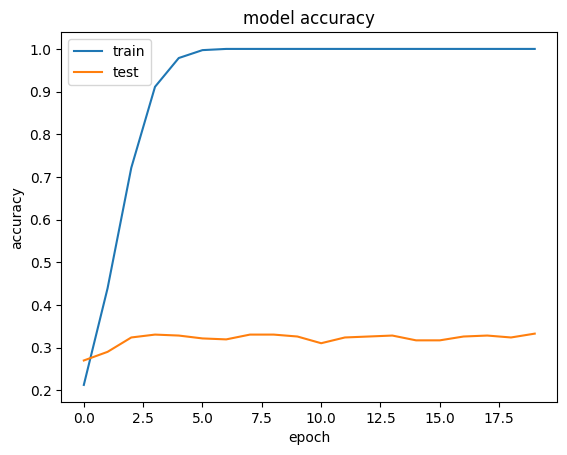

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

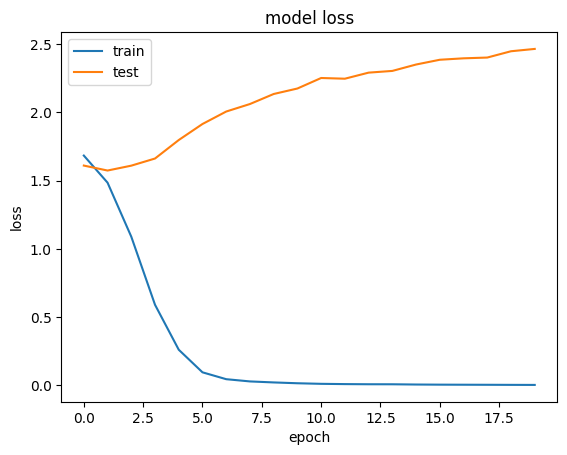

In [67]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [68]:
txt = ["blair prepares to name poll date tony blair is likely to name 5 may as election day when parliament returns from its easter break  the bbc s political editor has learned.  andrew marr says mr blair will ask the queen on 4 or 5 april to dissolve parliament at the end of that week. mr blair has so far resisted calls for him to name the day but all parties have stepped up campaigning recently. downing street would not be drawn on the claim  saying election timing was a matter for the prime minister.  a number 10 spokeswoman would only say:  he will announce an election when he wants to announce an election.  the move will signal a frantic week at westminster as the government is likely to try to get key legislation through parliament. the government needs its finance bill  covering the budget plans  to be passed before the commons closes for business at the end of the session on 7 april.  but it will also seek to push through its serious and organised crime bill and id cards bill. mr marr said on wednesday s today programme:  there s almost nobody at a senior level inside the government or in parliament itself who doesn t expect the election to be called on 4 or 5 april.  as soon as the commons is back after the short easter recess  tony blair whips up to the palace  asks the queen to dissolve parliament ... and we re going.  the labour government officially has until june 2006 to hold general election  but in recent years governments have favoured four-year terms."]

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['sport', 'bussiness', 'politics', 'tech', 'entertainment']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
[[1.4277674e-04 3.3568035e-04 2.0568768e-05 9.9886072e-01 2.6303701e-04
  3.7724679e-04]]
3
politics


In [69]:
txt = ["call to save manufacturing jobs the trades union congress (tuc) is calling on the government to stem job losses in manufacturing firms by reviewing the help it gives companies.  the tuc said in its submission before the budget that action is needed because of 105 000 jobs lost from the sector over the last year. it calls for better pensions  child care provision and decent wages. the 36-page submission also urges the government to examine support other european countries provide to industry. tuc general secretary brendan barber called for  a commitment to policies that will make a real difference to the lives of working people.    greater investment in childcare strategies and the people delivering that childcare will increases the options available to working parents   he said.  a commitment to our public services and manufacturing sector ensures that we can continue to compete on a global level and deliver the frontline services that this country needs.  he also called for  practical measures  to help pensioners  especially women who he said  are most likely to retire in poverty . the submission also calls for decent wages and training for people working in the manufacturing sector."]

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['sport', 'bussiness', 'politics', 'tech', 'entertainment']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[1.6389647e-04 3.0542369e-04 9.9905866e-01 8.1758662e-05 2.4747461e-04
  1.4282044e-04]]
2
bussiness


## LSTM

In [70]:
tf.keras.backend.clear_session()

In [71]:
# LSTM model
model = Sequential()
model.add(Embedding(vocab_size,embedding_dim ))
model.build(input_shape=(None, 100))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(embedding_dim)))
model.add(Dense(6,activation='softmax' ))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,822 (1.48 MB)

 Trainable params: 386,822 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [73]:
num_epochs = 20
history = model.fit(train_padded, training_label_seq, epochs=num_epochs,
                    validation_data=(validation_padded, validation_label_seq),
                    verbose=2)

Epoch 1/20
56/56 - 5s - 89ms/step - accuracy: 0.2551 - loss: 1.6474 - val_accuracy: 0.2539 - val_loss: 1.5502
Epoch 2/20
56/56 - 3s - 46ms/step - accuracy: 0.4000 - loss: 1.4719 - val_accuracy: 0.2539 - val_loss: 1.6565
Epoch 3/20
56/56 - 3s - 46ms/step - accuracy: 0.5258 - loss: 1.2794 - val_accuracy: 0.5933 - val_loss: 1.1402
Epoch 4/20
56/56 - 3s - 45ms/step - accuracy: 0.7169 - loss: 0.8884 - val_accuracy: 0.7348 - val_loss: 0.8637
Epoch 5/20
56/56 - 2s - 45ms/step - accuracy: 0.8669 - loss: 0.5002 - val_accuracy: 0.8472 - val_loss: 0.5279
Epoch 6/20
56/56 - 3s - 47ms/step - accuracy: 0.8545 - loss: 0.5044 - val_accuracy: 0.8247 - val_loss: 0.6445
Epoch 7/20
56/56 - 3s - 48ms/step - accuracy: 0.9444 - loss: 0.2432 - val_accuracy: 0.8652 - val_loss: 0.4587
Epoch 8/20
56/56 - 3s - 47ms/step - accuracy: 0.9556 - loss: 0.1809 - val_accuracy: 0.8562 - val_loss: 0.4490
Epoch 9/20
56/56 - 3s - 46ms/step - accuracy: 0.9798 - loss: 0.0927 - val_accuracy: 0.8921 - val_loss: 0.4285
Epoch 10/2

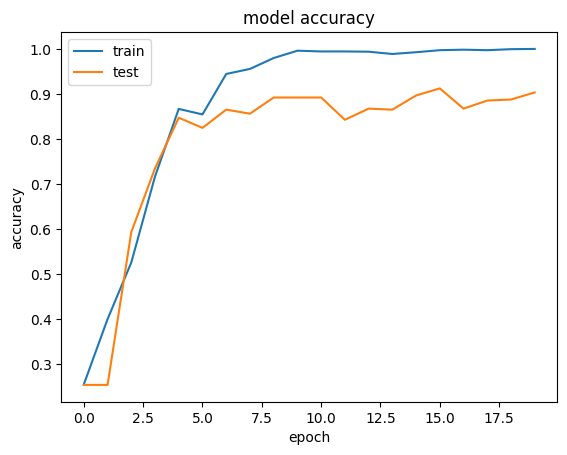

In [74]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

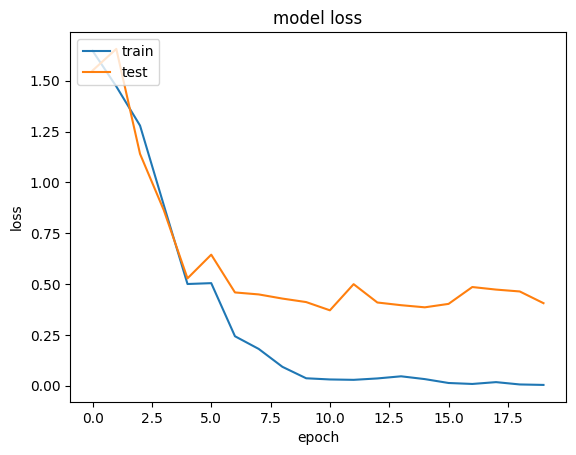

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


In [76]:
txt = ["blair prepares to name poll date tony blair is likely to name 5 may as election day when parliament returns from its easter break  the bbc s political editor has learned.  andrew marr says mr blair will ask the queen on 4 or 5 april to dissolve parliament at the end of that week. mr blair has so far resisted calls for him to name the day but all parties have stepped up campaigning recently. downing street would not be drawn on the claim  saying election timing was a matter for the prime minister.  a number 10 spokeswoman would only say:  he will announce an election when he wants to announce an election.  the move will signal a frantic week at westminster as the government is likely to try to get key legislation through parliament. the government needs its finance bill  covering the budget plans  to be passed before the commons closes for business at the end of the session on 7 april.  but it will also seek to push through its serious and organised crime bill and id cards bill. mr marr said on wednesday s today programme:  there s almost nobody at a senior level inside the government or in parliament itself who doesn t expect the election to be called on 4 or 5 april.  as soon as the commons is back after the short easter recess  tony blair whips up to the palace  asks the queen to dissolve parliament ... and we re going.  the labour government officially has until june 2006 to hold general election  but in recent years governments have favoured four-year terms."]

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['sport', 'bussiness', 'politics', 'tech', 'entertainment']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
[[3.7347406e-06 1.4354987e-03 4.9032510e-04 9.9773955e-01 3.2231087e-04
  8.5574211e-06]]
3
politics


In [77]:
txt = ["call to save manufacturing jobs the trades union congress (tuc) is calling on the government to stem job losses in manufacturing firms by reviewing the help it gives companies.  the tuc said in its submission before the budget that action is needed because of 105 000 jobs lost from the sector over the last year. it calls for better pensions  child care provision and decent wages. the 36-page submission also urges the government to examine support other european countries provide to industry. tuc general secretary brendan barber called for  a commitment to policies that will make a real difference to the lives of working people.    greater investment in childcare strategies and the people delivering that childcare will increases the options available to working parents   he said.  a commitment to our public services and manufacturing sector ensures that we can continue to compete on a global level and deliver the frontline services that this country needs.  he also called for  practical measures  to help pensioners  especially women who he said  are most likely to retire in poverty . the submission also calls for decent wages and training for people working in the manufacturing sector."]

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['sport', 'bussiness', 'politics', 'tech', 'entertainment']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[2.4478418e-06 2.1708494e-03 9.9339044e-01 3.1896734e-03 1.0149012e-05
  1.2365242e-03]]
2
bussiness
